# English to Spanish Translation via Transformer-based Mechanisms using Cross-Attention to map English source tokens to Spanish target tokens.

## Setup and Dependencies

In [1]:
# Install required packages
!pip install datasets tensorflow matplotlib numpy

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import string
import re

# Check GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Task 1: Preprocessing & Data Pipeline

- **Standardization**: Convert all text to lowercase and remove punctuation
- **Tokenization**: Prepend [start] and append [end] tokens to Spanish sentences
- **Vocabulary Constraint**: Max 15,000 words, max sequence length of 20 tokens

In [3]:
# Load the Anki Spanish-English dataset from HuggingFace
dataset = load_dataset("OscarNav/spa-eng")
print("Dataset structure:", dataset)
print("\nSample data:")
print(dataset['train'][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/429 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.58M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/623k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/107067 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11897 [00:00<?, ? examples/s]

Dataset structure: DatasetDict({
    train: Dataset({
        features: ['eng', 'spa'],
        num_rows: 107067
    })
    test: Dataset({
        features: ['eng', 'spa'],
        num_rows: 11897
    })
})

Sample data:
{'eng': 'When the curtain went up, the stage was dark.', 'spa': 'Al levantarse el telón, la escena estaba oscura.'}


In [4]:
# Extract sentence pairs and limit to first 50,000 pairs
MAX_SAMPLES = 50000

# Get the data
train_data = dataset['train']

# Extract English and Spanish sentences
english_sentences = []
spanish_sentences = []

for i, item in enumerate(train_data):
    if i >= MAX_SAMPLES:
        break
    english_sentences.append(item['eng'])
    spanish_sentences.append(item['spa'])

print(f"Total sentence pairs loaded: {len(english_sentences)}")
print(f"\nSample pairs:")
for i in range(5):
    print(f"EN: {english_sentences[i]}")
    print(f"ES: {spanish_sentences[i]}")
    print()

Total sentence pairs loaded: 50000

Sample pairs:
EN: When the curtain went up, the stage was dark.
ES: Al levantarse el telón, la escena estaba oscura.

EN: What was Tom doing the last time you saw him?
ES: ¿Qué estaba haciendo Tom la última vez que lo viste?

EN: Why don't you meet me at 2:30?
ES: ¿Por qué no te encuentras conmigo a las dos y media?

EN: I'll talk to Tom later.
ES: Hablaré con Tom más tarde.

EN: Tom was the one who cooked dinner.
ES: Tom fue el que cocinó la cena.



In [5]:

# Text standardization function
def standardize_text(text):
    """Convert to lowercase and remove punctuation."""
    text = text.lower()
    # Remove punctuation but keep spaces
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Standardize all sentences
english_sentences = [standardize_text(s) for s in english_sentences]
spanish_sentences = [standardize_text(s) for s in spanish_sentences]

print("After standardization:")
for i in range(3):
    print(f"EN: {english_sentences[i]}")
    print(f"ES: {spanish_sentences[i]}")
    print()

After standardization:
EN: when the curtain went up the stage was dark
ES: al levantarse el telón la escena estaba oscura

EN: what was tom doing the last time you saw him
ES: ¿qué estaba haciendo tom la última vez que lo viste

EN: why dont you meet me at 230
ES: ¿por qué no te encuentras conmigo a las dos y media



In [6]:
# Add [start] and [end] tokens to Spanish sentences
spanish_sentences_input = ['[start] ' + s for s in spanish_sentences]
spanish_sentences_target = [s + ' [end]' for s in spanish_sentences]

print("Spanish input (for decoder):")
print(spanish_sentences_input[0])
print("\nSpanish target (for training):")
print(spanish_sentences_target[0])

Spanish input (for decoder):
[start] al levantarse el telón la escena estaba oscura

Spanish target (for training):
al levantarse el telón la escena estaba oscura [end]


In [7]:
# Hyperparameters for vocabulary and sequence length
VOCAB_SIZE = 15000
MAX_SEQUENCE_LENGTH = 20

# Create TextVectorization layers
# English (source) vectorizer
english_vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQUENCE_LENGTH,
    standardize=None  # Already standardized
)

# Spanish (target) vectorizer
spanish_vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQUENCE_LENGTH + 1,  # +1 for start/end tokens
    standardize=None
)

# Adapt vectorizers to the data
english_vectorizer.adapt(english_sentences)
spanish_vectorizer.adapt(spanish_sentences_input + spanish_sentences_target)

print(f"English vocabulary size: {len(english_vectorizer.get_vocabulary())}")
print(f"Spanish vocabulary size: {len(spanish_vectorizer.get_vocabulary())}")
print(f"\nSample English vocabulary: {english_vectorizer.get_vocabulary()[:20]}")
print(f"\nSample Spanish vocabulary: {spanish_vectorizer.get_vocabulary()[:20]}")

English vocabulary size: 9979
Spanish vocabulary size: 15000

Sample English vocabulary: ['', '[UNK]', np.str_('the'), np.str_('i'), np.str_('to'), np.str_('you'), np.str_('tom'), np.str_('a'), np.str_('is'), np.str_('he'), np.str_('in'), np.str_('of'), np.str_('it'), np.str_('that'), np.str_('was'), np.str_('do'), np.str_('me'), np.str_('this'), np.str_('have'), np.str_('my')]

Sample Spanish vocabulary: ['', '[UNK]', np.str_('[start]'), np.str_('[end]'), np.str_('de'), np.str_('que'), np.str_('a'), np.str_('no'), np.str_('tom'), np.str_('la'), np.str_('el'), np.str_('en'), np.str_('es'), np.str_('un'), np.str_('me'), np.str_('se'), np.str_('él'), np.str_('lo'), np.str_('una'), np.str_('por')]


In [8]:
# Create the dataset pipeline
def create_dataset(eng_sentences, spa_input, spa_target, batch_size=64):
    """Create a TensorFlow dataset for training."""

    # Vectorize sentences
    eng_vectors = english_vectorizer(eng_sentences)
    spa_input_vectors = spanish_vectorizer(spa_input)
    spa_target_vectors = spanish_vectorizer(spa_target)

    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices((
        {'encoder_inputs': eng_vectors, 'decoder_inputs': spa_input_vectors},
        spa_target_vectors
    ))

    dataset = dataset.shuffle(buffer_size=len(eng_sentences))
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

# Split data into train, validation, and test sets
train_size = int(0.8 * len(english_sentences))
val_size = int(0.1 * len(english_sentences))

# Training set
train_eng = english_sentences[:train_size]
train_spa_input = spanish_sentences_input[:train_size]
train_spa_target = spanish_sentences_target[:train_size]

# Validation set
val_eng = english_sentences[train_size:train_size+val_size]
val_spa_input = spanish_sentences_input[train_size:train_size+val_size]
val_spa_target = spanish_sentences_target[train_size:train_size+val_size]

# Test set
test_eng = english_sentences[train_size+val_size:]
test_spa_input = spanish_sentences_input[train_size+val_size:]
test_spa_target = spanish_sentences_target[train_size+val_size:]

print(f"Training samples: {len(train_eng)}")
print(f"Validation samples: {len(val_eng)}")
print(f"Test samples: {len(test_eng)}")

# Create datasets
BATCH_SIZE = 64
train_dataset = create_dataset(train_eng, train_spa_input, train_spa_target, BATCH_SIZE)
val_dataset = create_dataset(val_eng, val_spa_input, val_spa_target, BATCH_SIZE)

Training samples: 40000
Validation samples: 5000
Test samples: 5000


---
## Task 2: The Multi-Head Cross-Attention Layer

Implementing a custom layer that facilitates information flow between English and Spanish:
- **Queries (Q)**: Derived from the Spanish (Decoder) sequence
- **Keys (K) & Values (V)**: Derived from the English (Encoder) source sequence
- Every decoder token attends to all encoder positions

In [9]:
class MultiHeadCrossAttention(layers.Layer):
    """
    Multi-Head Cross-Attention Layer

    This layer implements cross-attention where:
    - Queries come from the decoder (Spanish sequence)
    - Keys and Values come from the encoder (English sequence)


    """

    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads



        self.depth = d_model // num_heads  # d_k = d_v = d_model / num_heads

        # Linear projections for Q, K, V
        self.W_q = layers.Dense(d_model)  # Query projection (from decoder)
        self.W_k = layers.Dense(d_model)  # Key projection (from encoder)
        self.W_v = layers.Dense(d_model)  # Value projection (from encoder)

        # Output projection
        self.W_o = layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        """Split the last dimension into (num_heads, depth)."""
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])  # (batch, heads, seq_len, depth)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Calculate attention weights and apply to values.


        """
        # QK^T
        matmul_qk = tf.matmul(Q, K, transpose_b=True)

        # Scale by sqrt(d_k)
        d_k = tf.cast(tf.shape(K)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(d_k)

        # Apply mask (if provided)
        if mask is not None:
            scaled_attention_logits += (mask * -1e9)

        # Softmax to get attention weights
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)

        # Multiply by values
        output = tf.matmul(attention_weights, V)

        return output, attention_weights

    def call(self, decoder_input, encoder_output, mask=None):
        """
        Forward pass for cross-attention.

        Args:
            decoder_input: Output from decoder self-attention (Spanish)
            encoder_output: Output from encoder (English)
            mask: Optional padding mask

        Returns:
            Cross-attention output
        """
        batch_size = tf.shape(decoder_input)[0]

        # Project Q from decoder (Spanish)
        Q = self.W_q(decoder_input)  # Queries from decoder

        # Project K, V from encoder (English)
        K = self.W_k(encoder_output)  # Keys from encoder
        V = self.W_v(encoder_output)  # Values from encoder

        # Split into multiple heads
        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)

        # Apply scaled dot-product attention
        attention_output, attention_weights = self.scaled_dot_product_attention(Q, K, V, mask)

        # Concatenate heads
        attention_output = tf.transpose(attention_output, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention_output, (batch_size, -1, self.d_model))

        # Final linear projection
        output = self.W_o(concat_attention)

        return output

# Test the cross-attention layer
print("Testing Multi-Head Cross-Attention Layer:")
test_cross_attn = MultiHeadCrossAttention(d_model=256, num_heads=4)
test_decoder_input = tf.random.normal((2, 10, 256))  # (batch, spanish_seq, d_model)
test_encoder_output = tf.random.normal((2, 15, 256))  # (batch, english_seq, d_model)
test_output = test_cross_attn(test_decoder_input, test_encoder_output)
print(f"Decoder input shape: {test_decoder_input.shape}")
print(f"Encoder output shape: {test_encoder_output.shape}")
print(f"Cross-attention output shape: {test_output.shape}")

Testing Multi-Head Cross-Attention Layer:
Decoder input shape: (2, 10, 256)
Encoder output shape: (2, 15, 256)
Cross-attention output shape: (2, 10, 256)


In [10]:
class MultiHeadSelfAttention(layers.Layer):
    """
    Multi-Head Self-Attention Layer

    Used in both encoder and decoder for self-attention.
    Q, K, V all come from the same input sequence.
    """

    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.depth = d_model // num_heads

        self.W_q = layers.Dense(d_model)
        self.W_k = layers.Dense(d_model)
        self.W_v = layers.Dense(d_model)
        self.W_o = layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        matmul_qk = tf.matmul(Q, K, transpose_b=True)
        d_k = tf.cast(tf.shape(K)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(d_k)

        if mask is not None:
            scaled_attention_logits += (mask * -1e9)

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, V)

        return output, attention_weights

    def call(self, x, mask=None):
        batch_size = tf.shape(x)[0]

        # Q, K, V all from same input (self-attention)
        Q = self.split_heads(self.W_q(x), batch_size)
        K = self.split_heads(self.W_k(x), batch_size)
        V = self.split_heads(self.W_v(x), batch_size)

        attention_output, _ = self.scaled_dot_product_attention(Q, K, V, mask)

        attention_output = tf.transpose(attention_output, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention_output, (batch_size, -1, self.d_model))

        return self.W_o(concat_attention)

---
## Task 3: Encoder-Decoder Architecture

Building a simplified Transformer-style model:
- **Encoder**: Processes English words with self-attention
- **Decoder**: Processes Spanish words with self-attention + cross-attention
- Hyperparameters: d_model=256, num_heads=4

In [11]:
# Model Hyperparameters (as specified)
D_MODEL = 256
NUM_HEADS = 4
DFF = 512  # Feed-forward dimension
DROPOUT_RATE = 0.1

In [12]:
class PositionalEncoding(layers.Layer):
    """
    Positional Encoding layer to inject position information.
    Uses sinusoidal encoding as in the original Transformer paper.
    """

    def __init__(self, max_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
        self.d_model = d_model

        # Create positional encoding matrix
        position = np.arange(max_len)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)

        self.pe = tf.constant(pe, dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pe[:seq_len, :]

In [13]:
class TransformerEncoderBlock(layers.Layer):
    """
    Transformer Encoder Block:
    1. Multi-Head Self-Attention
    2. Add & Norm
    3. Feed-Forward Network
    4. Add & Norm
    """

    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)

        self.self_attention = MultiHeadSelfAttention(d_model, num_heads)
        self.ffn = keras.Sequential([
            layers.Dense(dff, activation='relu'),
            layers.Dense(d_model)
        ])

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, x, training=False, mask=None):
        # Self-attention with residual connection
        attn_output = self.self_attention(x, mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        x = self.layernorm1(x + attn_output)

        # Feed-forward with residual connection
        ffn_output = self.ffn(x)
        ffn_output = self.dropout2(ffn_output, training=training)
        x = self.layernorm2(x + ffn_output)

        return x

In [14]:
class TransformerDecoderBlock(layers.Layer):
    """
    Transformer Decoder Block:
    1. Masked Multi-Head Self-Attention
    2. Add & Norm
    3. Multi-Head Cross-Attention (with encoder output)
    4. Add & Norm
    5. Feed-Forward Network
    6. Add & Norm
    """

    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)

        # Masked self-attention for decoder
        self.self_attention = MultiHeadSelfAttention(d_model, num_heads)

        # Cross-attention to attend to encoder output
        self.cross_attention = MultiHeadCrossAttention(d_model, num_heads)

        self.ffn = keras.Sequential([
            layers.Dense(dff, activation='relu'),
            layers.Dense(d_model)
        ])

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)
        self.dropout3 = layers.Dropout(dropout_rate)

    def call(self, x, encoder_output, training=False, look_ahead_mask=None, padding_mask=None):
        # Masked self-attention
        self_attn_output = self.self_attention(x, mask=look_ahead_mask)
        self_attn_output = self.dropout1(self_attn_output, training=training)
        x = self.layernorm1(x + self_attn_output)

        # Cross-attention with encoder output
        cross_attn_output = self.cross_attention(x, encoder_output, mask=padding_mask)
        cross_attn_output = self.dropout2(cross_attn_output, training=training)
        x = self.layernorm2(x + cross_attn_output)

        # Feed-forward
        ffn_output = self.ffn(x)
        ffn_output = self.dropout3(ffn_output, training=training)
        x = self.layernorm3(x + ffn_output)

        return x

In [15]:
class TransformerEncoder(layers.Layer):
    """
    Full Transformer Encoder:
    - Embedding layer
    - Positional encoding
    - Stack of encoder blocks
    """

    def __init__(self, vocab_size, d_model, num_heads, dff, max_len,
                 num_layers=2, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)

        self.d_model = d_model
        self.embedding = layers.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(max_len, d_model)

        self.encoder_blocks = [
            TransformerEncoderBlock(d_model, num_heads, dff, dropout_rate)
            for _ in range(num_layers)
        ]

        self.dropout = layers.Dropout(dropout_rate)

    def call(self, x, training=False, mask=None):
        # Embedding and scaling
        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))

        # Add positional encoding
        x = self.pos_encoding(x)
        x = self.dropout(x, training=training)

        # Pass through encoder blocks
        for encoder_block in self.encoder_blocks:
            x = encoder_block(x, training=training, mask=mask)

        return x

In [16]:
class TransformerDecoder(layers.Layer):
    """
    Full Transformer Decoder:
    - Embedding layer
    - Positional encoding
    - Stack of decoder blocks (with cross-attention)
    """

    def __init__(self, vocab_size, d_model, num_heads, dff, max_len,
                 num_layers=2, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)

        self.d_model = d_model
        self.embedding = layers.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(max_len, d_model)

        self.decoder_blocks = [
            TransformerDecoderBlock(d_model, num_heads, dff, dropout_rate)
            for _ in range(num_layers)
        ]

        self.dropout = layers.Dropout(dropout_rate)

    def call(self, x, encoder_output, training=False, look_ahead_mask=None, padding_mask=None):
        # Embedding and scaling
        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))

        # Add positional encoding
        x = self.pos_encoding(x)
        x = self.dropout(x, training=training)

        # Pass through decoder blocks
        for decoder_block in self.decoder_blocks:
            x = decoder_block(x, encoder_output, training=training,
                            look_ahead_mask=look_ahead_mask,
                            padding_mask=padding_mask)

        return x

In [17]:
class Transformer(keras.Model):
    """
    Complete Transformer Model for English to Spanish Translation.

    Architecture:
    - Encoder: Processes English source sequence
    - Decoder: Generates Spanish target sequence with cross-attention to encoder
    """

    def __init__(self, source_vocab_size, target_vocab_size, d_model, num_heads,
                 dff, source_max_len, target_max_len, num_layers=2, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)

        self.encoder = TransformerEncoder(
            source_vocab_size, d_model, num_heads, dff, source_max_len,
            num_layers, dropout_rate
        )

        self.decoder = TransformerDecoder(
            target_vocab_size, d_model, num_heads, dff, target_max_len,
            num_layers, dropout_rate
        )

        # Final output layer to predict next token
        self.final_layer = layers.Dense(target_vocab_size)

    def create_look_ahead_mask(self, size):
        """Create causal mask to prevent attending to future tokens."""
        mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
        return mask

    def call(self, inputs, training=False):
        encoder_input = inputs['encoder_inputs']
        decoder_input = inputs['decoder_inputs']

        # Create look-ahead mask for decoder
        seq_len = tf.shape(decoder_input)[1]
        look_ahead_mask = self.create_look_ahead_mask(seq_len)

        # Encode the English source sequence
        encoder_output = self.encoder(encoder_input, training=training)

        # Decode with cross-attention to encoder output
        decoder_output = self.decoder(
            decoder_input, encoder_output,
            training=training,
            look_ahead_mask=look_ahead_mask
        )

        # Project to vocabulary size
        output = self.final_layer(decoder_output)

        return output

In [18]:
# Create the model with specified hyperparameters
source_vocab_size = len(english_vectorizer.get_vocabulary())
target_vocab_size = len(spanish_vectorizer.get_vocabulary())

print(f"Source (English) vocabulary size: {source_vocab_size}")
print(f"Target (Spanish) vocabulary size: {target_vocab_size}")
print(f"d_model: {D_MODEL}")
print(f"Number of attention heads: {NUM_HEADS}")

model = Transformer(
    source_vocab_size=source_vocab_size,
    target_vocab_size=target_vocab_size,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dff=DFF,
    source_max_len=MAX_SEQUENCE_LENGTH,
    target_max_len=MAX_SEQUENCE_LENGTH + 1,
    num_layers=2,
    dropout_rate=DROPOUT_RATE
)

# Build the model by passing sample data
sample_input = {
    'encoder_inputs': tf.zeros((1, MAX_SEQUENCE_LENGTH), dtype=tf.int32),
    'decoder_inputs': tf.zeros((1, MAX_SEQUENCE_LENGTH + 1), dtype=tf.int32)
}
_ = model(sample_input)

model.summary()

Source (English) vocabulary size: 9979
Target (Spanish) vocabulary size: 15000
d_model: 256
Number of attention heads: 4


Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ transformer_encoder             │ ?                      │     3,608,832 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder             │ ?                      │     5,421,568 │
│ (TransformerDecoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (1, 21, 15000)         │     3,855,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,885,400 (49.15 MB)

 Trainable params: 12,885,400 (49.15 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4: Training & Greedy Inference

- **Training**: 20 epochs with Adam optimizer
- **Inference**: Greedy search starting from [start] token until [end] or max length

In [19]:
# Custom learning rate schedule
class CustomSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

# Create optimizer with custom schedule
learning_rate = CustomSchedule(D_MODEL)
optimizer = keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

In [20]:
# Loss function with masking for padding tokens
loss_object = keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def masked_loss(y_true, y_pred):
    """Calculate loss while ignoring padding tokens (0)."""
    mask = tf.math.logical_not(tf.math.equal(y_true, 0))
    loss = loss_object(y_true, y_pred)

    mask = tf.cast(mask, dtype=loss.dtype)
    loss *= mask

    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    """Calculate accuracy while ignoring padding tokens."""
    y_pred_ids = tf.argmax(y_pred, axis=-1)
    y_pred_ids = tf.cast(y_pred_ids, y_true.dtype)

    match = tf.equal(y_true, y_pred_ids)
    mask = tf.math.logical_not(tf.math.equal(y_true, 0))

    match = tf.math.logical_and(match, mask)

    match = tf.cast(match, tf.float32)
    mask = tf.cast(mask, tf.float32)

    return tf.reduce_sum(match) / tf.reduce_sum(mask)

In [21]:
# Compile the model
model.compile(
    optimizer=optimizer,
    loss=masked_loss,
    metrics=[masked_accuracy]
)

In [22]:
# Training configuration
EPOCHS = 20

print(f"Training for {EPOCHS} epochs...")
print(f"Training samples: {len(train_eng)}")
print(f"Validation samples: {len(val_eng)}")

# Train the model
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    verbose=1
)

Training for 20 epochs...
Training samples: 40000
Validation samples: 5000
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 50ms/step - loss: 8.3797 - masked_accuracy: 0.1196 - val_loss: 5.4229 - val_masked_accuracy: 0.2524
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - loss: 4.9826 - masked_accuracy: 0.2888 - val_loss: 3.9004 - val_masked_accuracy: 0.4080
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - loss: 3.5847 - masked_accuracy: 0.4426 - val_loss: 3.0079 - val_masked_accuracy: 0.5333
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - loss: 2.7163 - masked_accuracy: 0.5525 - val_loss: 2.6207 - val_masked_accuracy: 0.5845
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - loss: 2.1978 - masked_accuracy: 0.6195 - val_loss: 2.3816 - val_masked_accuracy: 0.6089
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - loss: 1.8920 - masked_accuracy: 0.6544 - val_loss: 2.2897 - val_masked_accuracy: 0.6216
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - loss:

---
## Visual Proof: Training Loss vs Validation Loss

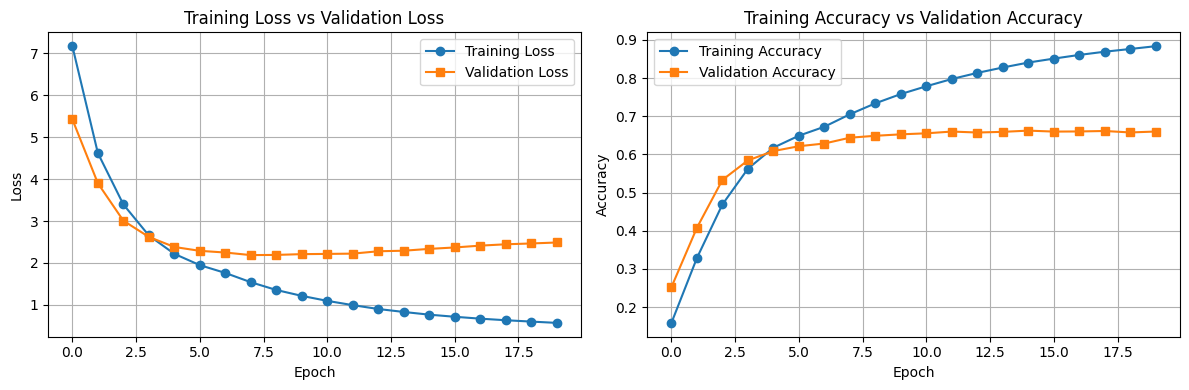


Final Training Loss: 0.5730
Final Validation Loss: 2.4883
Final Training Accuracy: 0.8838
Final Validation Accuracy: 0.6601


In [23]:
# Plot training and validation loss
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['masked_accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_masked_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Training Accuracy vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history.history['masked_accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_masked_accuracy'][-1]:.4f}")

---
## Greedy Inference Function

In [24]:
def greedy_decode(model, english_sentence, english_vectorizer, spanish_vectorizer, max_length=20):
    """
    Greedy search decoding for translation.

    The model starts with the [start] token and iteratively predicts
    the next Spanish word until [end] is generated or max_length is reached.

    Args:
        model: Trained Transformer model
        english_sentence: Input English sentence (string)
        english_vectorizer: English text vectorizer
        spanish_vectorizer: Spanish text vectorizer
        max_length: Maximum output sequence length

    Returns:
        Translated Spanish sentence (string)
    """
    # Get vocabulary
    spanish_vocab = spanish_vectorizer.get_vocabulary()
    spanish_index_lookup = dict(zip(range(len(spanish_vocab)), spanish_vocab))

    # Get special token indices
    start_token_idx = spanish_vocab.index('[start]') if '[start]' in spanish_vocab else 1
    end_token_idx = spanish_vocab.index('[end]') if '[end]' in spanish_vocab else 2

    # Vectorize the English input
    encoder_input = english_vectorizer([english_sentence])

    # Start with [start] token
    decoder_input = tf.constant([[start_token_idx]], dtype=tf.int32)

    # Greedy decoding loop
    output_tokens = []

    for _ in range(max_length):
        # Pad decoder input to max length
        padded_decoder_input = tf.keras.preprocessing.sequence.pad_sequences(
            decoder_input.numpy(), maxlen=max_length + 1, padding='post'
        )
        padded_decoder_input = tf.constant(padded_decoder_input, dtype=tf.int32)

        # Get model predictions
        predictions = model({
            'encoder_inputs': encoder_input,
            'decoder_inputs': padded_decoder_input
        }, training=False)

        # Get the last predicted token (greedy selection)
        current_pos = decoder_input.shape[1] - 1
        next_token_logits = predictions[0, current_pos, :]
        next_token_id = tf.argmax(next_token_logits).numpy()

        # Stop if [end] token is predicted
        if next_token_id == end_token_idx:
            break

        # Add token to output
        output_tokens.append(spanish_index_lookup.get(next_token_id, '[UNK]'))

        # Append to decoder input for next iteration
        decoder_input = tf.concat([
            decoder_input,
            tf.constant([[next_token_id]], dtype=tf.int32)
        ], axis=1)

    # Join tokens to form the translation
    translation = ' '.join(output_tokens)
    return translation

In [25]:
def translate_sentence(english_sentence):
    """
    Translate an English sentence to Spanish.
    """
    # Standardize input
    standardized = standardize_text(english_sentence)

    # Get translation using greedy decoding
    translation = greedy_decode(
        model, standardized, english_vectorizer, spanish_vectorizer,
        max_length=MAX_SEQUENCE_LENGTH
    )

    return translation

---
## Translation Samples: 5 Examples from Test Set

In [26]:
# Select 5 random examples from the test set
import random
random.seed(42)

test_indices = random.sample(range(len(test_eng)), 5)

print("=" * 80)
print("TRANSLATION SAMPLES FROM TEST SET")
print("=" * 80)

for i, idx in enumerate(test_indices, 1):
    source_english = test_eng[idx]
    target_spanish = spanish_sentences[train_size + val_size + idx]  # Original Spanish (without start/end)
    model_prediction = translate_sentence(source_english)

    print(f"\n--- Example {i} ---")
    print(f"Source English:    {source_english}")
    print(f"Target Spanish:    {target_spanish}")
    print(f"Model Prediction:  {model_prediction}")

TRANSLATION SAMPLES FROM TEST SET

--- Example 1 ---
Source English:    its perfectly harmless
Target Spanish:    es totalmente inofensivo
Model Prediction:  es perfectamente

--- Example 2 ---
Source English:    i think theres someone out there
Target Spanish:    creo que hay alguien ahí afuera
Model Prediction:  creo que hay alguien allá

--- Example 3 ---
Source English:    he was ignorant of the fact that the town had been destroyed
Target Spanish:    ignoraba el hecho de que la ciudad había sido destruida
Model Prediction:  él fue lejos de que el hecho de la ciudad tuvo [UNK]

--- Example 4 ---
Source English:    there was a lot of snow last year
Target Spanish:    el año pasado nevó mucho
Model Prediction:  había mucha nieve el año pasado

--- Example 5 ---
Source English:    wait a second
Target Spanish:    aguarda un segundo
Model Prediction:  espera un segundo


In [27]:
# Additional translations to demonstrate model capability
print("\n" + "=" * 80)
print("ADDITIONAL TRANSLATION EXAMPLES")
print("=" * 80)

test_sentences = [
    "Good morning, my friend.",
    "What time is it?",
    "I like this book.",
    "She is very smart.",
    "We are going home."
]

for sentence in test_sentences:
    translation = translate_sentence(sentence)
    print(f"\nEnglish: {sentence}")
    print(f"Spanish: {translation}")


ADDITIONAL TRANSLATION EXAMPLES

English: Good morning, my friend.
Spanish: buenos días a mi amigo

English: What time is it?
Spanish: ¿qué hora es

English: I like this book.
Spanish: me gusta este libro

English: She is very smart.
Spanish: ella es muy inteligente

English: We are going home.
Spanish: vamos a casa


---
## Brief Analysis: Self-Attention vs Cross-Attention (Max 250 words)

### Why Both Self-Attention and Cross-Attention Are Necessary for Translation?

**Self-Attention (Same Input Sequence):**
Self-attention allows a word to look at other words within the same sentence and understand relationship between each other. In the encoder, this helps the model build a rich understanding of the source language by capturing context, word relationships, and sentence structure even when related words are far apart.

In the decoder, self-attention is applied in a masked way so each generated word can only consider the words that came before it. This ensures the output sentence is produced step by step in a natural order resulting in fluent and grammatically correct text.

**Cross-Attention (Different Source Sequence):**
Cross-attention bridges the encoder and decoder allowing the decoder to relate with an entire English source sequence while generating Spanish output. Queries come from the decoder Spanish sentences while Keys and Values come from the encoder English sentences. This ensures that Spanish word is contextually grounded in the source meaning. Without cross-attention, the decoder would generate Spanish text without reference to the English input.

Both are essential because self-attention understands meaning within each language and cross-attention transfers that meaning across languages. Self-attention captures intra-language relationships (within English or within Spanish) while cross-attention captures inter-language alignment (English to Spanish).